# 05 – Entalpias de Reação & Calores de Combustão

Como o $H^\circ(T)$ do `pyglenn` é *padronizado* (já inclui a entalpia de
formação de cada espécie, notebook 04), a entalpia padrão de reação é meramente
uma soma estequiométrica de entalpias:

$$\Delta H_\mathrm{rxn}(T) = \sum_{\text{produtos}} \nu_j\,H^\circ_j(T)
   - \sum_{\text{reagentes}} \nu_i\,H^\circ_i(T).$$

Nada de tabela separada de entalpias de formação, nada de contabilidade com a
lei de Hess — uma chamada por espécie. Usamos isso para calcular calores de
combustão (PCI/PCS), sua dependência com a temperatura (lei de Kirchhoff) e para
demonstrar a lei de Hess.

> **Nota sobre o estado padrão de gás ideal:** As propriedades dos polinômios
> NASA representam o **estado padrão de gás ideal** (1 bar). Em altas pressões
> ou para misturas com fases condensadas, correções de não idealidade (ex.:
> coeficientes de fugacidade, equações de estado) devem ser aplicadas — os
> valores brutos de `h_relative` do `pyglenn` são o limite de gás ideal.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Uma função genérica para entalpia de reação

As reações são expressas como dicionários
`{nome_da_espécie: coeficiente_estequiométrico}`. O auxiliar retorna
$\Delta H_\mathrm{rxn}$ em J/mol em qualquer temperatura.

In [3]:
def reaction_enthalpy(calc, reactants, products, T=298.15):
    """Entalpia padrão de reação em J/mol na temperatura T (Kelvin)."""
    def total(mix):
        h = 0.0
        for name, nu in mix.items():
            h += nu * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
        return h
    return total(products) - total(reactants)

## 2. Validação contra reações conhecidas

Quatro reações clássicas de livros-texto a 298,15 K (água produto no estado
gasoso). Os valores calculados concordam com as entalpias de reação padrão
aceitas com erro de fração de kJ/mol.

In [4]:
REACTIONS = {
    "CO + 1/2 O2 -> CO2":              ({"CO": 1, "O2": 0.5}, {"CO2": 1}, -283.0),
    "H2 + 1/2 O2 -> H2O(g)":           ({"H2": 1, "O2": 0.5}, {"H2O": 1}, -241.8),
    "CH4 + 2 O2 -> CO2 + 2 H2O(g)":    ({"CH4": 1, "O2": 2}, {"CO2": 1, "H2O": 2}, -802.3),
    "C2H5OH + 3 O2 -> 2 CO2 + 3 H2O":  ({"C2H5OH": 1, "O2": 3}, {"CO2": 2, "H2O": 3}, -1277.5),
}

rows = []
with ThermochemicalCalculator() as calc:
    for label, (reac, prod, ref) in REACTIONS.items():
        dh = reaction_enthalpy(calc, reac, prod) / 1000.0
        rows.append({"reação": label, "pyglenn [kJ/mol]": dh,
                     "referência [kJ/mol]": ref, "erro": abs(dh - ref)})
print(pd.DataFrame(rows).set_index("reação").to_string())

                                pyglenn [kJ/mol]  referência [kJ/mol]  erro
reação                                                                     
CO + 1/2 O2 -> CO2                      -282.973             -283.000 0.027
H2 + 1/2 O2 -> H2O(g)                   -241.825             -241.800 0.025
CH4 + 2 O2 -> CO2 + 2 H2O(g)            -802.557             -802.300 0.257
C2H5OH + 3 O2 -> 2 CO2 + 3 H2O        -1,277.541           -1,277.500 0.041


## 3. Calores de combustão (Poder Calorífico Inferior)

O **poder calorífico inferior** (PCI, ou LHV) é o calor liberado por mol de
combustível com a água produto permanecendo como **vapor**:
$\text{PCI} = -\Delta H_\mathrm{comb}$. Nós o calculamos para uma variedade de
combustíveis e também o expressamos por quilograma, a figura de mérito para
combustíveis de transporte.

In [5]:
# combustível -> (mols O2, produto CO2, produto H2O) para combustão completa
FUELS = {
    "H2":               (0.5, 0, 1),
    "CH4":              (2.0, 1, 2),
    "C3H8":             (5.0, 3, 4),
    "C2H5OH":           (3.0, 2, 3),
    "C8H18,isooctane":  (12.5, 8, 9),
}

def molar_mass(calc, name):
    sid = calc.get_available_species(name, exact_match=True)[0]["id"]
    return calc.db.get_species_data(sid)["molecular_weight"]

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (nO2, nCO2, nH2O) in FUELS.items():
        dh = reaction_enthalpy(calc, {fuel: 1, "O2": nO2},
                               {"CO2": nCO2, "H2O": nH2O})
        lhv = -dh                       # J/mol
        M = molar_mass(calc, fuel)      # g/mol
        rows.append({"combustível": fuel, "M [g/mol]": M,
                     "PCI [kJ/mol]": lhv / 1000.0,
                     "PCI [MJ/kg]": lhv / M / 1000.0})

lhv_df = pd.DataFrame(rows).set_index("combustível").sort_values("PCI [MJ/kg]", ascending=False)
print(lhv_df.to_string())

                 M [g/mol]  PCI [kJ/mol]  PCI [MJ/kg]
combustível                                          
H2                   2.016       241.825      119.960
CH4                 16.042       802.557       50.027
C3H8                44.096     2,043.142       46.334
C8H18,isooctane    114.229     5,100.475       44.652
C2H5OH              46.068     1,277.541       27.731


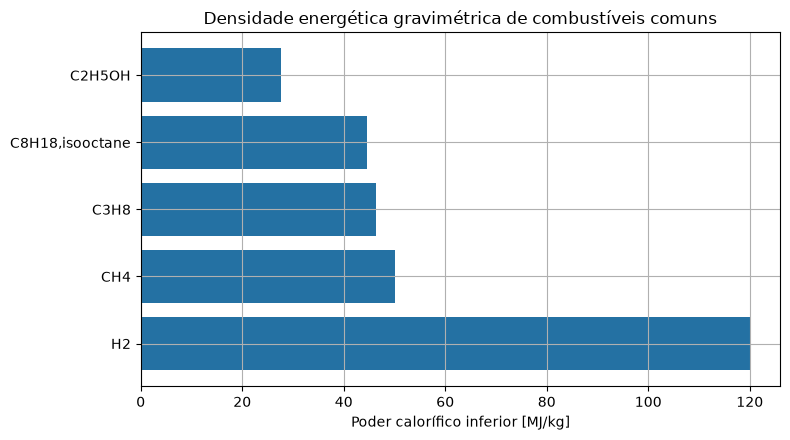

In [6]:
fig, ax = plt.subplots()
ax.barh(lhv_df.index, lhv_df["PCI [MJ/kg]"], color="#2471a3")
ax.set_xlabel("Poder calorífico inferior [MJ/kg]")
ax.set_title("Densidade energética gravimétrica de combustíveis comuns")
fig.tight_layout()
plt.show()

## 4. Poder Calorífico Superior (PCS)

Se a água produto condensar para o estado **líquido**, seu calor latente é
recuperado e a energia liberada é maior — o **poder calorífico superior**. A
diferença é a entalpia de vaporização da água produzida:

$$\text{PCS} = \text{PCI} + n_{\mathrm{H_2O}}\,\Delta_\mathrm{vap} H_{\mathrm{H_2O}},
\qquad \Delta_\mathrm{vap} H \approx 44{,}0\ \text{kJ/mol a 298 K}.$$

Obtemos $\Delta_\mathrm{vap}H$ do próprio banco de dados como
$H^\circ_{\mathrm{H_2O(g)}} - H^\circ_{\mathrm{H_2O(L)}}$ quando a água líquida
está na faixa, usando 44,0 kJ/mol como alternativa.

In [7]:
with ThermochemicalCalculator() as calc:
    gas = calc.calculate_properties(calc.get_available_species("H2O", exact_match=True)[0]["id"], 298.15)["h_relative"]
    liqp = calc.calculate_properties(calc.get_available_species("H2O(L)", exact_match=True)[0]["id"], 298.15)
    dvap = (gas - liqp["h_relative"]) / 1000.0
    source = "banco de dados (H2O gás - H2O líquido)"
print(f"Entalpia de vaporização da água utilizada: {dvap:.2f} kJ/mol  [{source}]")

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (nO2, nCO2, nH2O) in FUELS.items():
        lhv = -reaction_enthalpy(calc, {fuel: 1, "O2": nO2},
                                 {"CO2": nCO2, "H2O": nH2O}) / 1000.0
        hhv = lhv + nH2O * dvap
        rows.append({"combustível": fuel, "PCI [kJ/mol]": lhv, "PCS [kJ/mol]": hhv,
                     "PCS-PCI [kJ/mol]": hhv - lhv})
print(pd.DataFrame(rows).set_index("combustível").to_string())

Entalpia de vaporização da água utilizada: 44.00 kJ/mol  [banco de dados (H2O gás - H2O líquido)]
                 PCI [kJ/mol]  PCS [kJ/mol]  PCS-PCI [kJ/mol]
combustível                                                  
H2                    241.825       285.828            44.004
CH4                   802.557       890.565            88.008
C3H8                2,043.142     2,219.158           176.015
C2H5OH              1,277.541     1,409.552           132.012
C8H18,isooctane     5,100.475     5,496.509           396.035


## 5. Dependência com a temperatura — lei de Kirchhoff

A entalpia de reação varia com a temperatura porque produtos e reagentes
possuem diferentes capacidades caloríficas:

$$\frac{d(\Delta H_\mathrm{rxn})}{dT} = \Delta C_p
  = \sum_{\text{prod}}\nu_j C_{p,j} - \sum_{\text{reag}}\nu_i C_{p,i}.$$

Plotamos $\Delta H_\mathrm{rxn}(T)$ para a combustão do metano e do hidrogênio.
Ambas são funções fracas de $T$ ($\Delta C_p$ pequeno), razão pela qual calores
de combustão à temperatura ambiente são frequentemente usados em uma ampla faixa.

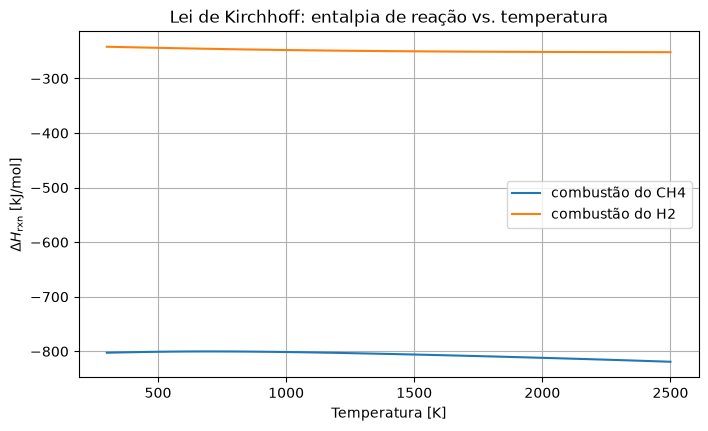

In [8]:
Tgrid = np.linspace(300, 2500, 60)
combustions = {
    "combustão do CH4": ({"CH4": 1, "O2": 2}, {"CO2": 1, "H2O": 2}),
    "combustão do H2":  ({"H2": 1, "O2": 0.5}, {"H2O": 1}),
}
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label, (reac, prod) in combustions.items():
        dh = [reaction_enthalpy(calc, reac, prod, T) / 1000.0 for T in Tgrid]
        ax.plot(Tgrid, dh, label=label)
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel(r"$\Delta H_\mathrm{rxn}$ [kJ/mol]")
ax.set_title("Lei de Kirchhoff: entalpia de reação vs. temperatura")
ax.legend()
plt.show()

## 6. Lei de Hess

A entalpia de reação é uma função de estado: o caminho em duas etapas
C(gr)→CO→CO₂ deve somar o mesmo que o caminho direto C(gr)→CO₂. O `pyglenn`
respeita isso automaticamente porque toda entalpia está na mesma escala
padronizada.

In [9]:
with ThermochemicalCalculator() as calc:
    step1 = reaction_enthalpy(calc, {"C(gr)": 1, "O2": 0.5}, {"CO": 1})
    step2 = reaction_enthalpy(calc, {"CO": 1, "O2": 0.5}, {"CO2": 1})
    direct = reaction_enthalpy(calc, {"C(gr)": 1, "O2": 1}, {"CO2": 1})

print(f"C(gr) + 1/2 O2 -> CO      : {step1/1000:8.2f} kJ/mol")
print(f"CO    + 1/2 O2 -> CO2     : {step2/1000:8.2f} kJ/mol")
print(f"soma das duas etapas      : {(step1+step2)/1000:8.2f} kJ/mol")
print(f"direto C(gr) + O2 -> CO2  : {direct/1000:8.2f} kJ/mol")
assert np.isclose(step1 + step2, direct)
print("\nA lei de Hess é satisfeita exatamente.")

C(gr) + 1/2 O2 -> CO      :  -110.53 kJ/mol
CO    + 1/2 O2 -> CO2     :  -282.97 kJ/mol
soma das duas etapas      :  -393.51 kJ/mol
direto C(gr) + O2 -> CO2  :  -393.51 kJ/mol

A lei de Hess é satisfeita exatamente.


## Resumo

- Entalpia de reação é uma soma estequiométrica de entalpias padronizadas em uma
  linha.
- PCI (água vapor) e PCS (água líquida) seguem imediatamente; valores por kg
  classificam combustíveis para transporte.
- A lei de Kirchhoff fornece a dependência com a temperatura; a lei de Hess é
  automática.

**A seguir:** o notebook 06 usa o mesmo balanço de entalpia para calcular
temperaturas de chama adiabática.